Uma loja virtual quer analisar o comportamento de compra de seus clientes.

Crie uma simulação com 10.000 clientes, contendo:

idade dos clientes entre 18 e 70 anos;
renda mensal seguindo uma distribuição normal com média 3000 e desvio padrão 800;
clientes com 40 anos ou mais têm probabilidade de compra de 55%;
clientes com menos de 40 anos têm probabilidade de compra de 30%.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# Configurando a semente para reprodutibilidade
np.random.seed(0)

# Criando os dados simulados
n = 10000
# Gerar idades entre 18 e 70 anos
idades = np.random.randint(18, 71, n)
# Gerar rendas com uma distribuição normal, com média de 3000 e desvio padrão de 800, e limitar as rendas a um mínimo de 800
rendas = np.random.normal(3000, 800, n)
rendas = np.clip(rendas, 800, None)
# Gerar a variável de compra com uma probabilidade que depende da idade, onde pessoas com 40 anos ou mais têm uma probabilidade de compra de 0.55, e pessoas com menos de 40 anos têm uma probabilidade de compra de 0.30
prob_compra = np.where(idades >= 40, 0.55, 0.30)

comprou = np.random.random(n) < prob_compra

df = pd.DataFrame({
    "idade": idades,
    "renda": rendas,
    "comprou": comprou
})

df["faixa_idade"] = np.where(df["idade"] >= 40, "40 anos ou mais", "menos de 40")

Qual é a média, mediana, moda, desvio padrão e variância da renda?

In [ ]:
df["renda"].mean() #Calcular a média da coluna 'renda' do DataFrame usando a função mean() do Pandas para obter o valor médio de renda no conjunto de dados.

np.float64(2994.9931326307387)

In [ ]:
df["renda"].median() #Calcular a mediana da coluna 'renda' do DataFrame usando a função median() do Pandas para obter o valor central de renda no conjunto de dados, e comparar a média e a mediana para entender a distribuição dos dados de renda.

np.float64(2985.5119817247905)

In [ ]:
stats.mode(df["idade"], keepdims=True).mode[0] #Calcular a moda da coluna 'idade' do DataFrame usando a função mode() do SciPy para obter o valor mais frequente de idade no conjunto de dados, e entender a diferença entre média, mediana e moda como medidas de tendência central.

np.int32(35)

In [ ]:
df["renda"].std() #Calcular o desvio padrão da coluna 'renda' do DataFrame usando a função std() do Pandas para medir a dispersão dos valores de renda em relação à média, e entender a importância do desvio padrão como medida de dispersão.

np.float64(792.4935434623653)

In [ ]:
df["renda"].var() #Calcular a variância da coluna 'renda' do DataFrame usando a função var() do Pandas para medir a dispersão dos valores de renda em relação à média, e entender a relação entre variância e desvio padrão, onde a variância é o quadrado do desvio padrão.

np.float64(628046.0164295359)

Faça um histograma da renda.

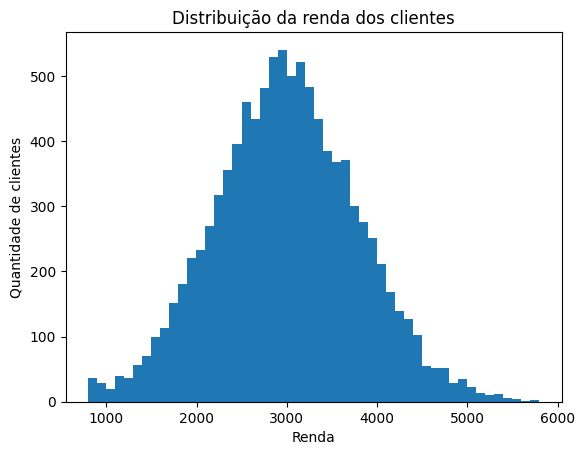

In [ ]:
plt.hist(df["renda"], bins=50)
plt.title("Distribuição da renda dos clientes")
plt.xlabel("Renda")
plt.ylabel("Quantidade de clientes")
plt.show() #Criar um histograma da coluna 'renda' do DataFrame usando a função hist() do Matplotlib para visualizar a distribuição dos dados de renda, e entender a forma da distribuição, como assimetria e presença de outliers.

Faça um boxplot da renda por faixa etária.

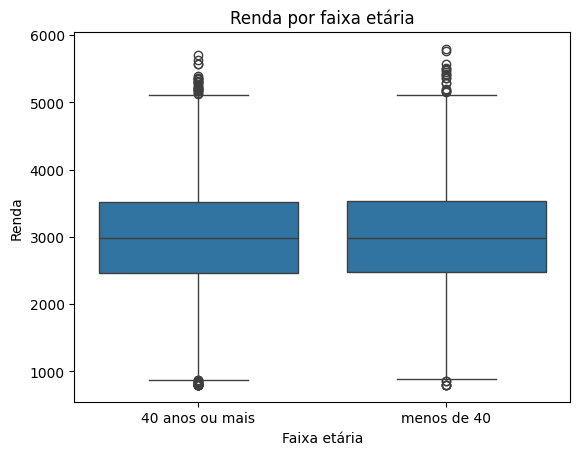

In [ ]:
sns.boxplot(x="faixa_idade", y="renda", data=df)
plt.title("Renda por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Renda")
plt.show() #Criar um boxplot da coluna 'renda' agrupada pela coluna 'faixa_idade' do DataFrame usando a função boxplot() do Seaborn para comparar a distribuição de renda entre as faixas etárias, e entender as diferenças na dispersão e presença de outliers entre os grupos.

Calcule:

P(compra):

In [ ]:
df["comprou"].mean()     #Calcular a proporção de clientes que compraram o produto usando a função mean() do Pandas na coluna 'comprou' do DataFrame, onde os valores True são tratados como 1 e os valores False como 0, para obter a taxa de compra no conjunto de dados.

np.float64(0.4473)

P(40 anos ou mais):

In [ ]:
(df["faixa_idade"] == "40 anos ou mais").mean() #Calcular a proporção de clientes com 40 anos ou mais usando a função mean() do Pandas na condição (df["faixa_idade"] == "40 anos ou mais"), onde os valores True são tratados como 1 e os valores False como 0, para entender a distribuição etária dos clientes no conjunto de dados.

np.float64(0.5916)

P(compra | 40 anos ou mais):

In [ ]:
df[df["faixa_idade"] == "40 anos ou mais"]["comprou"].mean() #Calcular a proporção de clientes com 40 anos ou mais que compraram o produto usando a função mean() do Pandas na condição (df["faixa_idade"] == "40 anos ou mais") aplicada à coluna 'comprou', para entender a taxa de compra específica para essa faixa etária.

np.float64(0.5431034482758621)

P(compra e 40 anos ou mais):

In [ ]:
((df["comprou"] == True) & (df["faixa_idade"] == "40 anos ou mais")).mean() #Calcular a proporção de clientes que compraram o produto e têm 40 anos ou mais usando a função mean() do Pandas na condição combinada ((df["comprou"] == True) & (df["faixa_idade"] == "40 anos ou mais")), onde os valores True são tratados como 1 e os valores False como 0, para entender a taxa de compra específica para clientes com 40 anos ou mais.

np.float64(0.3213)